<a href="https://colab.research.google.com/github/allatop/networks/blob/main/_2n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pickle

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Первые 5 значений цены (в тысячах долларов): {y[:5]}")

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_731/2435715361.py:12: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


X shape: (506, 13), y shape: (506,)
Первые 5 значений цены (в тысячах долларов): [24.  21.6 34.7 33.4 36.2]


#### 1.2. Проектируем архитектуру для этой задачи

In [ ]:
model = Sequential([
    Input(shape=(13,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Линейная активация по умолчанию для регрессии
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

#### 1.4. Обучаем модель ИНС

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

with open('boston_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 584.6278 - mae: 22.2361 - val_loss: 504.1396 - val_mae: 20.8580
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 531.9885 - mae: 20.9873 - val_loss: 463.3820 - val_mae: 19.8350
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 517.4495 - mae: 20.5932 - val_loss: 416.0246 - val_mae: 18.5652
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 432.2676 - mae: 18.4769 - val_loss: 361.0202 - val_mae: 17.0043
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 353.3656 - mae: 16.5447 - val_loss: 297.8884 - val_mae: 15.2207
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 327.1691 - mae: 15.4898 - val_loss: 228.9070 - val_mae: 13.1302
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 237.0374 - mae: 13.1809 - val_loss: 162.7024 - val_mae: 10.8438
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 171.0576 - mae: 10.9567 - val_loss: 102.9256 - val_mae: 8.2902
Epoch 9/1

#### 1.6. Делаем предсказания на тестовых данных

In [ ]:
predictions = model.predict(X_test_scaled, verbose=0)

#### 1.7. Вычисляем метрику качества на тестовых данных

In [ ]:
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print(f"MSE (Среднеквадратичная ошибка): {mse:.2f}")
print(f"MAE (Средняя абсолютная ошибка): {mae:.2f}")
print(f"R2 (Коэффициент детерминации):   {r2:.3f}")
print(f"Средняя ошибка предсказания: ~${mae*1000:.0f}")

МЕТРИКИ КАЧЕСТВА МОДЕЛИ
MSE (Среднеквадратичная ошибка): 13.72
MAE (Средняя абсолютная ошибка): 2.50
R2 (Коэффициент детерминации):   0.813
Средняя ошибка предсказания: ~$2495


#### 1.8. Строим график обучения

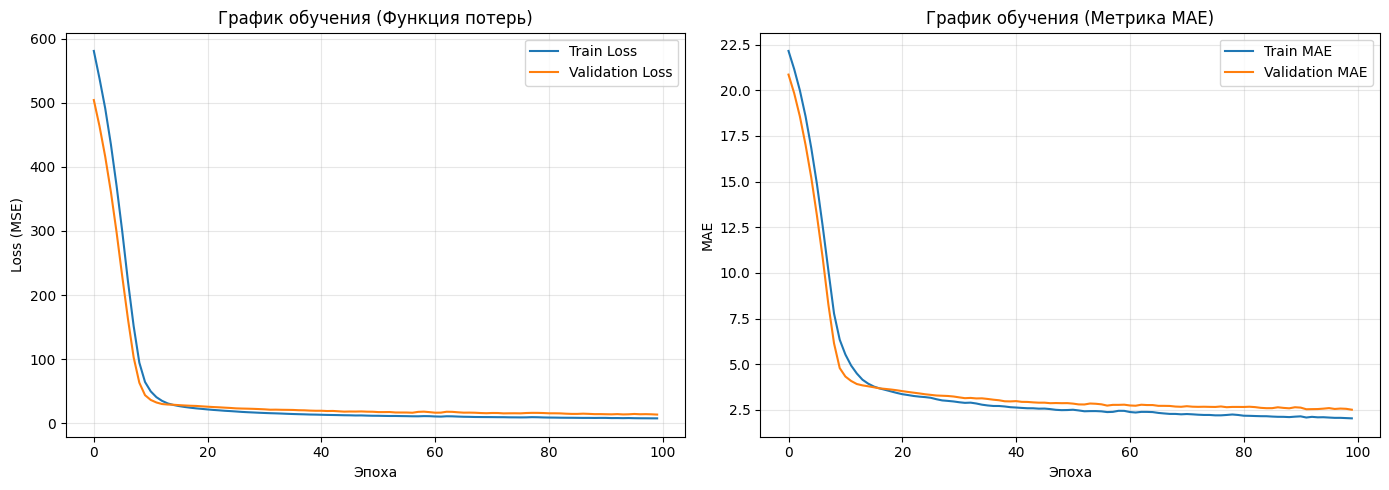

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('График обучения (Функция потерь)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.title('График обучения (Метрика MAE)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [ ]:
!pip install gradio -q
import gradio as gr

def predict_price(*features):
    """
    Функция прогнозирует цену на основе 13 входных признаков.
    Использует сохраненный scaler и модель.
    """
    try:

        input_data = np.array([features])
        with open('boston_scaler.pkl', 'rb') as f:
            scaler = pickle.load(f)

        input_scaled = scaler.transform(input_data)

        prediction = model.predict(input_scaled, verbose=0)[0][0]

        return f"${prediction * 1000:.2f}"

    except Exception as e:
        return f"Ошибка: {e}"

interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="CRIM: Уровень преступности на душу населения"),
        gr.Number(label="ZN: Доля жилой земли, выделенная под участки > 25000 кв. футов"),
        gr.Number(label="INDUS: Доля неторговых акров в городе"),
        gr.Number(label="CHAS: Фиктивная переменная (1 - у реки, 0 - нет)"),
        gr.Number(label="NOX: Концентрация оксидов азота (в 10 млн-1)"),
        gr.Number(label="RM: Среднее количество комнат в жилом помещении"),
        gr.Number(label="AGE: Доля жилых единиц, построенных до 1940 года"),
        gr.Number(label="DIS: Взвешенное расстояние до пяти бостонских центров занятости"),
        gr.Number(label="RAD: Индекс доступности к радиальным магистралям"),
        gr.Number(label="TAX: Ставка налога на недвижимость (на 10 000 долларов)"),
        gr.Number(label="PTRATIO: Соотношение учеников и учителей в городе"),
        gr.Number(label="B: 1000*(Bk - 0.63)^2, где Bk - доля афроамериканцев в городе"),
        gr.Number(label="LSTAT: Процент населения с низким статусом"),
    ],
    outputs=gr.Textbox(label="Предсказанная стоимость (в долларах)"),
    title="🏠 Калькулятор цен на недвижимость в Бостоне",
    description="Введите характеристики района и дома, чтобы получить оценку его стоимости.",
    allow_flagging="never"
)

interface.launch(share=True, debug=False)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://85689e44d8627ce852.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### 2. Проверка обученной модели пользовательскими данными

In [ ]:
print("ПРОВЕРКА МОДЕЛИ НА СЛУЧАЙНЫХ ПРИМЕРАХ ИЗ ТЕСТОВОЙ ВЫБОРКИ")

for i in range(5):
    idx = np.random.randint(0, len(X_test_scaled))
    pred = model.predict(X_test_scaled[idx:idx+1], verbose=0)[0][0]
    actual = y_test[idx]
    error = abs(pred - actual)

    print(f"\nПример #{i+1}:")
    print(f"  Предсказано: ${pred*1000:.2f}")
    print(f"  Фактическое: ${actual*1000:.2f}")
    print(f"  Ошибка: ${error*1000:.2f} ({error/actual*100:.1f}%)")

ПРОВЕРКА МОДЕЛИ НА СЛУЧАЙНЫХ ПРИМЕРАХ ИЗ ТЕСТОВОЙ ВЫБОРКИ

Пример #1:
  Предсказано: $26685.45
  Фактическое: $25200.00
  Ошибка: $1485.45 (5.9%)

Пример #2:
  Предсказано: $21403.33
  Фактическое: $20000.00
  Ошибка: $1403.33 (7.0%)

Пример #3:
  Предсказано: $18776.72
  Фактическое: $13600.00
  Ошибка: $5176.72 (38.1%)

Пример #4:
  Предсказано: $18896.68
  Фактическое: $21200.00
  Ошибка: $2303.32 (10.9%)

Пример #5:
  Предсказано: $18592.63
  Фактическое: $19600.00
  Ошибка: $1007.37 (5.1%)


## **Задание №2.Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from imutils import paths
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import pickle
import cv2
import os
from tqdm import tqdm
import gradio as gr

### 2. Загружаем набор данных:

In [ ]:

!curl -L -o animal-image-datasetdog-cat-and-panda.zip \
  https://www.kaggle.com/api/v1/datasets/download/ashishsaxena2209/animal-image-datasetdog-cat-and-panda


!unzip -q animal-image-datasetdog-cat-and-panda.zip -d dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  375M  100  375M    0     0   106M      0  0:00:03  0:00:03 --:--:--  138M


### 3. Указываем путь к набору данных:

In [ ]:
DATASET_PATH = '/content/dataset/animals/animals'

### 4. Загружаем набор данных и формируем общую выборку:

In [ ]:
# Ваш код

#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [ ]:
from tqdm import tqdm
IMG_SIZE = 128
INPUT_DIM = IMG_SIZE * IMG_SIZE * 3

imagePaths = sorted(list(paths.list_images(DATASET_PATH)))
random.seed(42)
random.shuffle(imagePaths)

data = []
labels = []

for imagePath in tqdm(imagePaths, desc="Загрузка изображений"):
    try:
        image = cv2.imread(imagePath)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)).flatten()
        data.append(image)
        label = imagePath.split(os.path.sep)[-2]
        labels.append(label)
    except:
        continue

data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)

print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Classes: {np.unique(labels)}")

Загрузка изображений: 100%|██████████| 3000/3000 [00:09<00:00, 304.55it/s]


Data shape: (3000, 49152)
Labels shape: (3000,)
Classes: ['cats' 'dogs' 'panda']


#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [ ]:
lb = LabelBinarizer()
labels_encoded = lb.fit_transform(labels)

trainX, testX, trainY, testY = train_test_split(
    data, labels_encoded, test_size=0.25, random_state=42
)

print(f"Train: {trainX.shape}")
print(f"Test: {testX.shape}")

Train: (2250, 49152)
Test: (750, 49152)


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [ ]:
model = Sequential([
    Dense(1024, input_shape=(INPUT_DIM,), activation='relu'),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(len(lb.classes_), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1024)           │    50,332,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,989,571 (194.51 MB)

 Trainable params: 50,989,571 (194.51 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [ ]:
INIT_LR = 0.0001
EPOCHS = 100
BATCH_SIZE = 128

#### 5.3. Компилируем модель:

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=INIT_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_animal_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

callbacks = [early_stopping, checkpoint]

#### 6.2. Запустим процесс обучения модели:

In [ ]:
history = model.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3668 - loss: 2.1529

18/18 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.3700 - loss: 2.1216 - val_accuracy: 0.5307 - val_loss: 0.9026
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5342 - loss: 0.8946 - val_accuracy: 0.5200 - val_loss: 0.9451
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5429 - loss: 0.8625 - val_accuracy: 0.5027 - val_loss: 0.9969
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5605 - loss: 0.8348

18/18 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.5602 - loss: 0.8360 - val_accuracy: 0.5773 - val_loss: 0.8560
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5861 - loss: 0.8009

18/18 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.5864 - loss: 0.8015 - val_accuracy: 0.5880 - val_loss: 0.8582
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6016 - loss: 0.7871 - val_accuracy: 0.5760 - val_loss: 0.9078
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6040 - loss: 0.7842 - val_accuracy: 0.5800 - val_loss: 0.8484
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6125 - loss: 0.7832

18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6139 - loss: 0.7818 - val_accuracy: 0.6067 - val_loss: 0.8227
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6830 - loss: 0.6995 - val_accuracy: 0.5533 - val_loss: 0.8961
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.6663 - loss: 0.6967 - val_accuracy: 0.5667 - val_loss: 0.8832
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.6190 - loss: 0.7293 - val_accuracy: 0.5960 - val_loss: 0.8488
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7178 - loss: 0.6589 - val_accuracy: 0.5467 - val_loss: 0.9724
Epoch 13/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6915 - loss: 0.6781 - val_accuracy: 0.5880 - val_loss: 0.9010
Epoch 14/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6917 - loss: 0.6677 - val_accuracy: 0.5880 - val_loss: 0.8641
Epoch 15/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7202 - loss: 0.6281 - val_accuracy: 0.5720 - val_los

#### 6.3. Загружаем лучшую модель:

In [ ]:
model = load_model('best_animal_model.h5')
print("Лучшая модель загружена")

Лучшая модель загружена


### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [ ]:
preds = model.predict(testX)
pred_classes = preds.argmax(axis=1)
true_classes = testY.argmax(axis=1)

print(classification_report(true_classes, pred_classes, target_names=lb.classes_))

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step
              precision    recall  f1-score   support

        cats       0.53      0.73      0.61       236
        dogs       0.47      0.34      0.40       236
       panda       0.80      0.73      0.76       278

    accuracy                           0.61       750
   macro avg       0.60      0.60      0.59       750
weighted avg       0.61      0.61      0.60       750



#### 7.2. Выведем матрицу ошибок

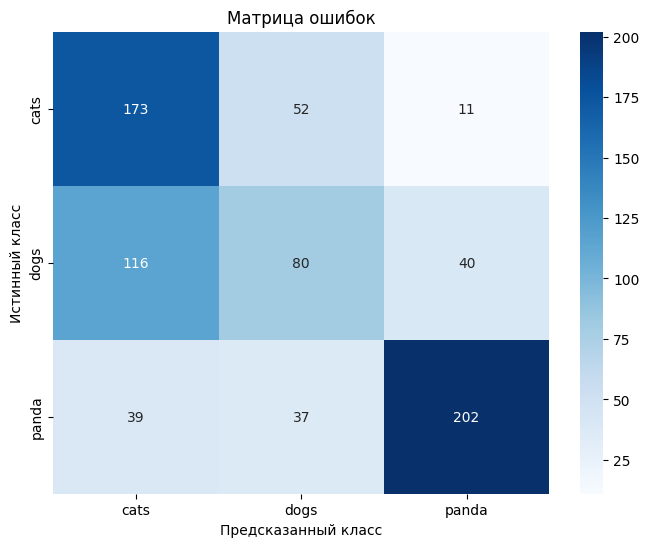

In [ ]:
conf_mat = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.title('Матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

#### 7.3. Отобразим график обучения

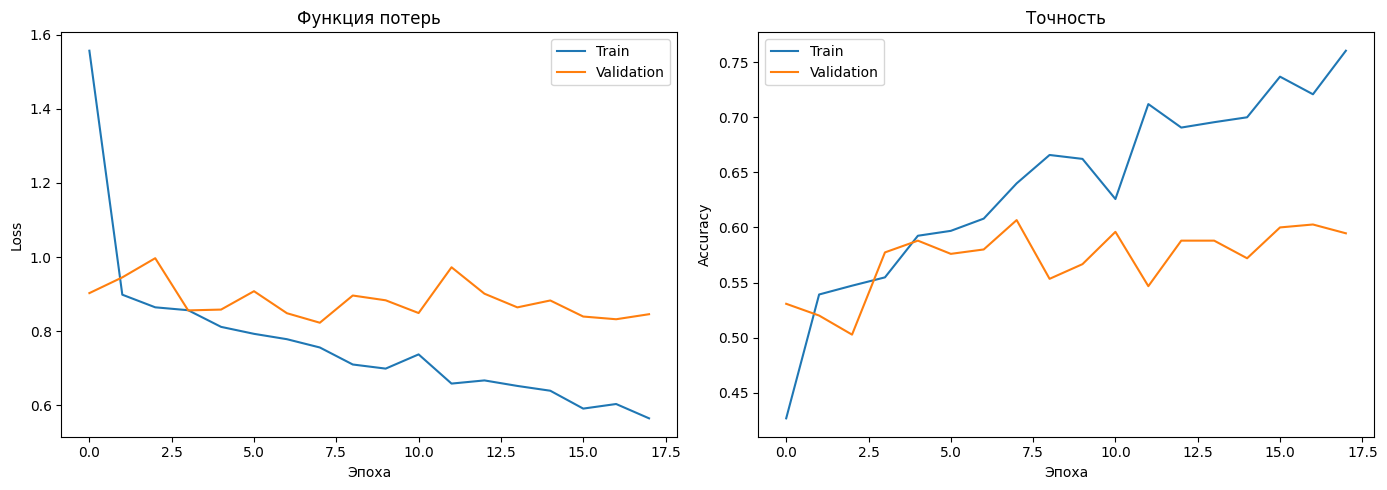

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 8. Сохранение модели и меток классов:

In [ ]:
model.save('animal_classifier_final.h5')
with open('label_binarizer.pkl', 'wb') as f:
    pickle.dump(lb, f)

print("Модель сохранена: animal_classifier_final.h5")
print("Метки сохранены: label_binarizer.pkl")

Модель сохранена: animal_classifier_final.h5
Метки сохранены: label_binarizer.pkl


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [ ]:
# Ваш код

#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [ ]:
def preprocess_image(image, img_size=128):
    """
    Предобработка изображения для модели
    """
    if isinstance(image, str):
        image = cv2.imread(image)

    image = cv2.resize(image, (img_size, img_size))
    image = image.flatten().astype('float32') / 255.0
    image = image.reshape(1, -1)

    return image

#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [ ]:
def predict_animal(image):
    """
    Предсказание класса животного
    """
    # Загружаем модель и метки
    model = load_model('animal_classifier_final.h5')
    with open('label_binarizer.pkl', 'rb') as f:
        lb = pickle.load(f)

    # Предобработка
    processed = preprocess_image(image)

    # Предсказание
    preds = model.predict(processed, verbose=0)[0]

    # Результаты
    results = {lb.classes_[i]: float(preds[i]) for i in range(len(preds))}
    return results

### 10. Визуализируем интерфейс и произведем классификацию:

In [ ]:
# Создаем Gradio интерфейс
iface = gr.Interface(
    fn=predict_animal,
    inputs=gr.Image(label="Загрузите изображение"),
    outputs=gr.Label(label="Результат", num_top_classes=3),
    title="🐱🐶🐼 Классификатор животных",
    description="Загрузите фото кошки, собаки или панды"
)

# Запускаем
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1dd664a712e63e8fc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
